In [1]:
import radiate as rd
import polars as pl

rd.random.seed(67123)

### Create a fake dataset 

This dataset is a simple polynomial regression problem with a small it of noise

In [2]:
def compute(x: float) -> float:
    return 4.0 * x**3 - 3.0 * x**2 + x


inputs = []
answers = []

input = -1.0
for _ in range(-10, 10):
    input += 0.1
    inputs.append([input])
    answers.append([compute(input)])

### Create expressions

1. The first expression is a rolling mean of the species count for visualization purposes.
2. The second expression calculates the error of the species count rolling mean compared to the current species count.
3. The third expression calculates a threshold for the NEAT distance based on the last species threshold. 

The third threshold is essentially equivalent to something like

```python
def species_threshold(target_species: int) -> rd.Expr:
    GAIN = 0.3
    target = float(max(target_species, 1))

    count_error = (
        rd.Expr.select("count.species").rolling(target_species).mean() - target
    ) / target

    step = (count_error * GAIN + 1.0).clamp(0.8, 1.5)
    prev = rd.Expr.select("species.threshold").last()

    result = (prev * step).clamp(0.005, 2.0)
    return result
```

In [14]:
target_species = 4

rolling_species_count = rd.Expr.select("count.species").rolling(25).mean()
species_count_error = (
    rd.Expr.select("count.species").rolling(target_species).mean().error(target_species)
)

threshold = rd.Expr.track(
    "count.species",
    target=target_species,
    anchor=rd.Expr.select("species.threshold").last(),  # integrator
    gain=0.1,
    lo=0.05,
    hi=2.0,
)

err = rd.Expr.select("count.species").error(target_species).rolling(25).mean()

### Create the engine

This engine evolves `rd.Graph`s to fit the polynomial regression problem. The vertices of the graph are only allowed to use addition, multiplication, and constants. The engine also tracks the species count and species threshold as metrics, and uses the NEAT distance as a diversity metric.

In [ ]:
collector = rd.MetricCollector()

engine = (
    rd.Engine.graph(
        shape=(1, 1),
        vertex=[rd.Op.sub(), rd.Op.mul(), rd.Op.linear()],
        edge=rd.Op.weight(),
        output=rd.Op.linear(),
    )
    .regression(inputs, answers, loss=rd.MSE)
    .subscribe(collector)
    .diversity(rd.NeatDistance(), threshold)
    .metrics(
        species_rolling=rolling_species_count,
        species_count_error=species_count_error,
        other_threshold=threshold,
        err=err,
    )
    .alters(
        rd.Cross.graph(0.05, 0.5),
        rd.Mutate.op(0.07, 0.05),
        rd.Mutate.graph(0.1, 0.1, False),
    )
    .limit(rd.Limit.score(0.001), rd.Limit.generations(1000))
)

result = engine.run(log=True)

2026-06-03T22:44:08.578492Z  INFO Epoch 1    | Score:   2.0038 | Time: 310.42µs
2026-06-03T22:44:08.578781Z  INFO Epoch 2    | Score:   1.9043 | Time: 504.00µs
2026-06-03T22:44:08.579079Z  INFO Epoch 3    | Score:   1.9043 | Time: 714.83µs
2026-06-03T22:44:08.579382Z  INFO Epoch 4    | Score:   1.8232 | Time: 933.08µs
2026-06-03T22:44:08.579712Z  INFO Epoch 5    | Score:   1.7377 | Time: 1.17ms
2026-06-03T22:44:08.580042Z  INFO Epoch 6    | Score:   1.6844 | Time: 1.43ms
2026-06-03T22:44:08.580485Z  INFO Epoch 7    | Score:   1.6844 | Time: 1.77ms
2026-06-03T22:44:08.581611Z  INFO Epoch 8    | Score:   1.6844 | Time: 2.13ms
2026-06-03T22:44:08.582137Z  INFO Epoch 9    | Score:   1.6821 | Time: 2.53ms
2026-06-03T22:44:08.582782Z  INFO Epoch 10   | Score:   1.6820 | Time: 3.01ms
2026-06-03T22:44:08.583377Z  INFO Epoch 11   | Score:   1.6820 | Time: 3.46ms
2026-06-03T22:44:08.583779Z  INFO Epoch 12   | Score:   1.6820 | Time: 3.74ms
2026-06-03T22:44:08.584177Z  INFO Epoch 13   | Score:   

### Metrics

Using the `rd.MetricCollector` we can aggregate the metrics for the whole engine's run and visualize the metrics we want to track here once the engine has finished. In this case we only want to see our three expressions, but we could also see any `rd.Metric` that the engine tracks - refer to the docs for more details.

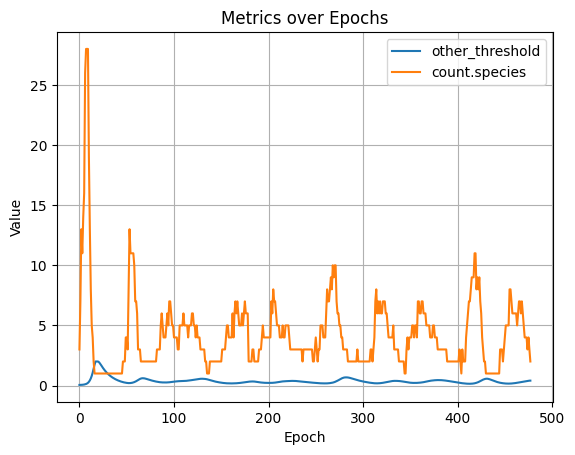

In [16]:
collector.plot(
    "other_threshold", "count.species"
)  # , "species_rolling", "species_count_error", "err")
# collector.plot("err")

In [17]:
df = collector.to_polars()
df.filter(pl.col("name") == "count.species").tail(20)
# df

name,last,sum,mean,stddev,var,skew,min,max,count,time_sum,time_mean,time_stddev,time_min,time_max,time_var,generation,update_count,tags
str,f64,f64,f64,f64,f64,f64,f64,f64,i64,duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],i64,i64,list[str]
"""count.species""",6.0,1926.0,4.196078,3.353403,11.245313,4.102242,1.0,28.0,459,null,null,null,null,null,null,458,1,"[""species"", ""statistic""]"
"""count.species""",6.0,1932.0,4.2,3.350804,11.227887,4.100023,1.0,28.0,460,null,null,null,null,null,null,459,1,"[""species"", ""statistic""]"
"""count.species""",6.0,1938.0,4.203905,3.348209,11.210506,4.097827,1.0,28.0,461,null,null,null,null,null,null,460,1,"[""species"", ""statistic""]"
"""count.species""",6.0,1944.0,4.207792,3.34562,11.193171,4.095651,1.0,28.0,462,null,null,null,null,null,null,461,1,"[""species"", ""statistic""]"
"""count.species""",6.0,1950.0,4.211663,3.343035,11.17588,4.093496,1.0,28.0,463,null,null,null,null,null,null,462,1,"[""species"", ""statistic""]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""count.species""",4.0,2011.0,4.242616,3.314744,10.987525,4.084243,1.0,28.0,474,null,null,null,null,null,null,473,1,"[""species"", ""statistic""]"
"""count.species""",3.0,2014.0,4.24,3.311736,10.967595,4.090418,1.0,28.0,475,null,null,null,null,null,null,474,1,"[""species"", ""statistic""]"
"""count.species""",4.0,2018.0,4.239496,3.308266,10.944627,4.096424,1.0,28.0,476,null,null,null,null,null,null,475,1,"[""species"", ""statistic""]"


In [7]:
df = collector.to_polars()
df

name,last,sum,mean,stddev,var,skew,min,max,count,time_sum,time_mean,time_stddev,time_min,time_max,time_var,generation,update_count,tags
str,f64,f64,f64,f64,f64,f64,f64,f64,i64,duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],i64,i64,list[str]
"""count.evaluation""",8.0,108.0,54.0,65.053825,4232.0,NaN,8.0,100.0,2,null,null,null,null,null,null,0,2,"[""statistic""]"
"""step.evaluate.time""",0.00001,0.000077,0.000039,0.00004,1.6127e-9,NaN,0.00001,0.000067,2,77µs,38µs,40µs,10µs,66µs,0µs,0,2,"[""time"", ""step""]"
"""selector.roulette""",20.0,20.0,20.0,0.0,0.0,NaN,20.0,20.0,1,null,null,null,null,null,null,0,1,"[""selector"", ""statistic""]"
"""selector.roulette.time""",0.000006,0.000006,0.000006,0.0,0.0,NaN,0.000006,0.000006,1,5µs,5µs,0µs,5µs,5µs,0µs,0,1,"[""selector"", ""time""]"
"""selector.tournament""",80.0,80.0,80.0,0.0,0.0,NaN,80.0,80.0,1,null,null,null,null,null,null,0,1,"[""selector"", ""statistic""]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""species_rolling""",2.2,1234.78064,4.60739,1.394277,1.944008,8.364057,2.12,12.333333,268,null,null,null,null,null,null,267,1,"[""species"", ""statistic"", ""expr""]"
"""species_count_error""",0.6875,22.645834,0.084499,0.969853,0.940615,0.0,-0.75,3.0,268,null,null,null,null,null,null,267,1,"[""species"", ""statistic"", ""expr""]"
"""other_threshold""",0.05,135.27269,0.504749,0.517485,0.267791,0.0,0.05,2.0,268,null,null,null,null,null,null,267,1,"[""other"", ""statistic"", ""expr""]"


In [8]:
print(result.index())
last_version = df.select("generation").max().item()
last_version

268


267